In [18]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [25]:
#define State

class BMIState(TypedDict):

    weight_kg:float
    height_m:float
    bmi:float
    category:str

In [26]:
def claculate_bmi(state:BMIState)->BMIState:

    weight=state['weight_kg']
    height=state['height_m']
    bmi= weight/(height**2)

    state['bmi']=round(bmi,2)

    return state

In [30]:
def label_bmi(state:BMIState)->BMIState:

    bmi=state['bmi']

    if bmi<18.5:
        state['category']="Underweigt"
    elif 18.5<= bmi<25:
        state['category']="Noraml"
    elif 25<= bmi < 30:
        state['category']="Overweight"
    else:
        state['category']="Obese"

    return {'category':state['category']}

In [31]:
#define graph

graph=StateGraph(BMIState)

#add nodes to your graph
graph.add_node('claculate_bmi',claculate_bmi)
graph.add_node('label_bmi',label_bmi)

#add edges to graph
graph.add_edge(START,'claculate_bmi')
graph.add_edge('claculate_bmi','label_bmi')

graph.add_edge('label_bmi',END)

#compile the graph
workflow=graph.compile()




In [32]:
#execute the graph
inital_state={'weight_kg':80,'height_m':1.73}

final_state=workflow.invoke(inital_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


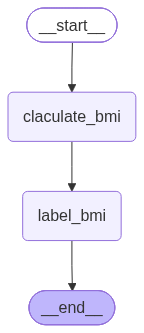

In [33]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())